<a href="https://colab.research.google.com/github/shin-jini/BUPA_Case_Study/blob/main/Descriptive_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# SECTION 1:
#Payment data Insights: Descriptive and Diagnostic Analytics

In [2]:
pd.options.display.float_format = '{:.2f}'.format
payments = pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Payments_Master.csv')
team=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Research_team_Master.csv',sep=';')
members=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Research_Team_members_Master.csv')
fraud=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Fraud_Cases_Master.csv')
print("Payments")
display(payments.head(2))
print("Research team")
display(team.head(2))
print("Team Members")
display(members.head(2))
print("Fraud")
display(fraud.head(2))
payments.isnull().sum().to_frame(name='missing').T

Payments


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,Date of payment,Payment amount,Payment authoriser,Payment Status,Type of expense,Company,phone_number,email
0,2025-04-27,Genetics,Melinda White,2025-04-14,INV-76915,"""Procured DNA extraction kits for isolating hi...",13319.94,2025-05-11,Kevin Ross,2025-06-09,2025-05-29,13319.94,Antonio Wilson,Paid,Software Licenses,IG Group Holdings,(624)900-2038x3126,uayers@ig.com
1,2025-06-02,Immunology,Daniel Peterson,2025-05-28,INV-64102,"""Purchase of endotoxin-free reagents for in vi...",14696.98,2025-06-14,Sarah Collins,2025-07-06,2025-06-22,14696.98,Antonio Wilson,Paid,Clinical Trial,Workspace Group,3967724119,jose87@workspace.com


Research team


,Research team,Director,Location,Affiliation,Research type,Annual budget,Item type,Item budget,Comments
0,Oncology,Gabriel Sullivan,Zurich,Harvard,Basic Research,21680552.51,Personnel,621512.01,Skin operation part short focus establish assu...
1,Oncology,Kyle Mckay,Munich,ETH Zurich,Basic Research,26683921.43,IT Infrastructure,3320269.70,Raise recently room or.


Team Members


,Team,Location,Name,Role
0,Oncology,Zurich,Christopher Wilson,Manager
1,Oncology,Zurich,Leslie Bradley,Analyst


Fraud


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,Date of payment,Payment amount,Payment authoriser,Payment Status,Type of expense,Fraud flag,Company,phone_number,email
0,2025-04-21,Immunology,Lauren Houston,2025-04-18,INV-02278,"""Procured immunohistochemistry staining kits f...",19366.92,2025-04-26,Sarah Collins,2025-06-05,2025-05-05,19366.92,Antonio Wilson,Paid,Lab Supplies,1,Quilter,(584)219-2504x7930,brandonramirez@quilter.com
1,2025-01-20,Neurology,Carlos Martin,2025-01-19,INV-78486,"""Subscription to specialized neuroscience data...",6839.49,2025-02-04,Dennis White,2025-03-06,2025-02-08,6839.49,Antonio Wilson,Paid,Travel,1,Volution Group,744.798.1953x276,lopezjennifer@volution.com


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,Date of payment,Payment amount,Payment authoriser,Payment Status,Type of expense,Company,phone_number,email
missing,0,0,0,0,0,0,0,0,0,0,572,572,0,0,0,0,0,0


In [3]:
payments['data']='payments'
fraud['data']='fraud'
in_num=set(payments['Invoice number']).intersection(set(fraud['Invoice number']))

combined_df = pd.concat([payments[~payments['Invoice number'].isin(in_num)], fraud], ignore_index=True)

date_cols = ['Date received', 'Date of invoice', 'Date of authorisation', 'Payment due date', 'Date of payment']
for col in date_cols:
    combined_df[col] = pd.to_datetime(combined_df[col], errors='coerce')

combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2978 entries, 0 to 2977
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date received          2978 non-null   datetime64[ns]
 1   Research team          2978 non-null   object        
 2   Submitted by           2978 non-null   object        
 3   Date of invoice        2978 non-null   datetime64[ns]
 4   Invoice number         2978 non-null   object        
 5   Description of spend   2978 non-null   object        
 6   Invoice value          2978 non-null   float64       
 7   Date of authorisation  2978 non-null   datetime64[ns]
 8   Authorised by          2978 non-null   object        
 9   Payment due date       2978 non-null   datetime64[ns]
 10  Date of payment        2111 non-null   datetime64[ns]
 11  Payment amount         2111 non-null   float64       
 12  Payment authoriser     2978 non-null   object        
 13  Pay

In [4]:
len(in_num)

22

In [5]:
# get location of payment
payment_merge=combined_df.merge(members, how='left', left_on=['Research team', 'Submitted by'],
    right_on=['Team', 'Name']).drop(columns=['Team', 'Name','phone_number','email'])

# Calculate Average Payement time:
payment_merge['avg_pay_time']=(payment_merge['Date of payment'] - payment_merge['Date received']).dt.days

# Calculate total budget
budget=budget=team.groupby(['Research team']).agg({"Annual budget":'sum'}).fillna(0).reset_index()
payment_merge=payment_merge.merge(budget, how='left', on='Research team')
display(payment_merge.head(2))
display(payment_merge.isnull().sum().to_frame(name='missing').T)

,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,...,Payment authoriser,Payment Status,Type of expense,Company,data,Fraud flag,Location,Role,avg_pay_time,Annual budget
0,2025-04-27,Genetics,Melinda White,2025-04-14,INV-76915,"""Procured DNA extraction kits for isolating hi...",13319.94,2025-05-11,Kevin Ross,2025-06-09,...,Antonio Wilson,Paid,Software Licenses,IG Group Holdings,payments,NaN,Boston,Analyst,32.00,48398165.75
1,2025-06-02,Immunology,Daniel Peterson,2025-05-28,INV-64102,"""Purchase of endotoxin-free reagents for in vi...",14696.98,2025-06-14,Sarah Collins,2025-07-06,...,Antonio Wilson,Paid,Clinical Trial,Workspace Group,payments,NaN,Zurich,Manager,20.00,80093835.11


,Date received,Research team,Submitted by,Date of invoice,Invoice number,Description of spend,Invoice value,Date of authorisation,Authorised by,Payment due date,...,Payment authoriser,Payment Status,Type of expense,Company,data,Fraud flag,Location,Role,avg_pay_time,Annual budget
missing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1978,0,0,867,0


Identify the research teams with the highest spend; budget utilization
---



In [6]:
team_stats= payment_merge.groupby("Research team").agg({"Payment amount":['mean','sum','count'],"Date of invoice": ['min', 'max'],'Annual budget': 'first'}).sort_values(('Payment amount', 'sum'), ascending=False)
team_stats['Utilization %'] = (team_stats[('Payment amount', 'sum')] * 100/ team_stats[('Annual budget', 'first')])
team_stats

Payment amount                  Date of invoice             \
                        mean        sum count             min        max   
Research team                                                              
Oncology            10827.70 4211976.96   389      2025-01-01 2025-07-11   
Genetics             9990.14 3976076.95   398      2025-01-04 2025-07-13   
Virology            10291.56 3900499.95   379      2025-01-04 2025-07-15   
Immunology           9965.54 2979696.12   299      2025-01-01 2025-07-13   
Neurology           10590.28 2859374.54   270      2025-01-08 2025-07-10   
Endocrinology       10363.24 2673716.06   258      2025-01-06 2025-07-09   
Cardiology          10038.11 1184497.47   118      2025-01-04 2025-07-06   

              Annual budget Utilization %  
                      first                
Research team                              
Oncology        89358802.58          4.71  
Genetics        48398165.75          8.22  
Virology        85451993.15          4.56  
Immunology      80093835.11          3.72  
Neurology       91981613.23          3.11  
Endocrinology   81254909.11          3.29  
Cardiology      66429524.51          1.78

# Track volume and time trends by category and location;

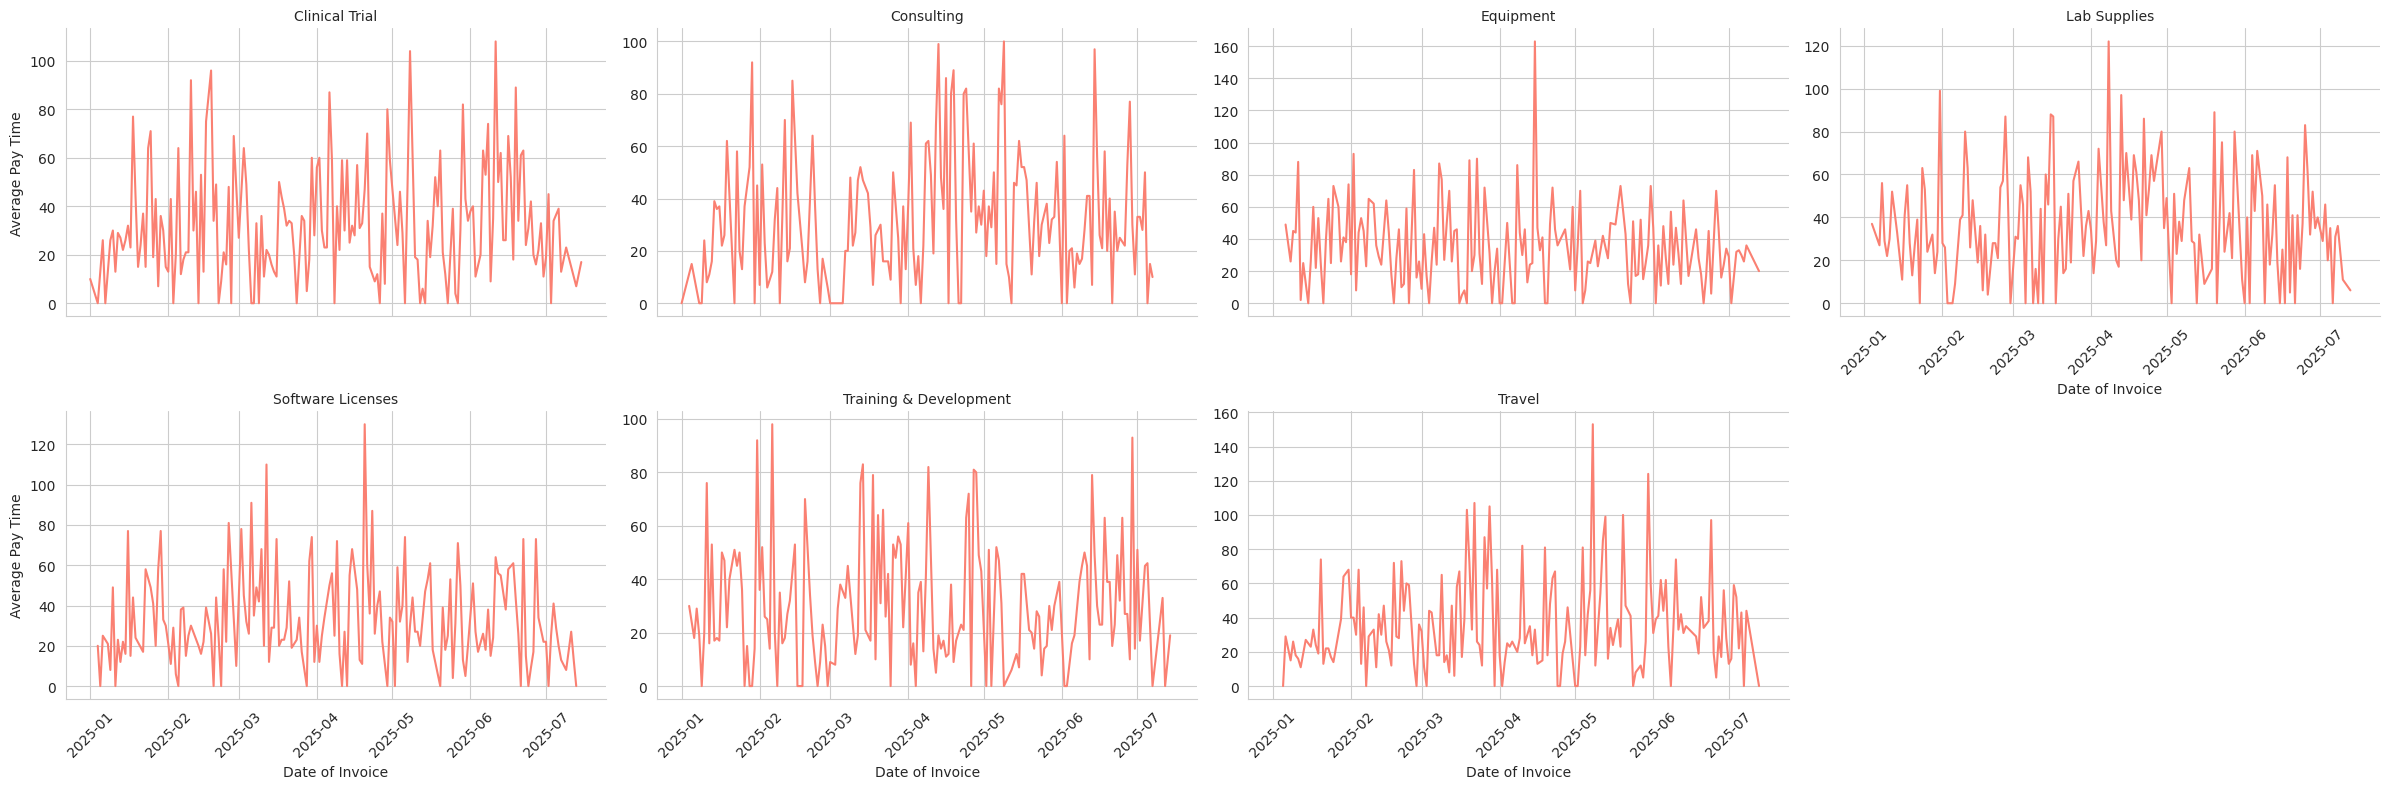

In [7]:
# Grouping by Category and Date to aggregate invoice values
plot_data = payment_merge.groupby(['Type of expense', 'Date of invoice'])['avg_pay_time'].sum().reset_index()

# Plotting
sns.set_style("whitegrid")
g = sns.FacetGrid(plot_data, col="Type of expense", col_wrap=4, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "Date of invoice", "avg_pay_time",color="salmon")

# Formatting
g.set_titles("{col_name}")
g.set_axis_labels("Date of Invoice", "Average Pay Time")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

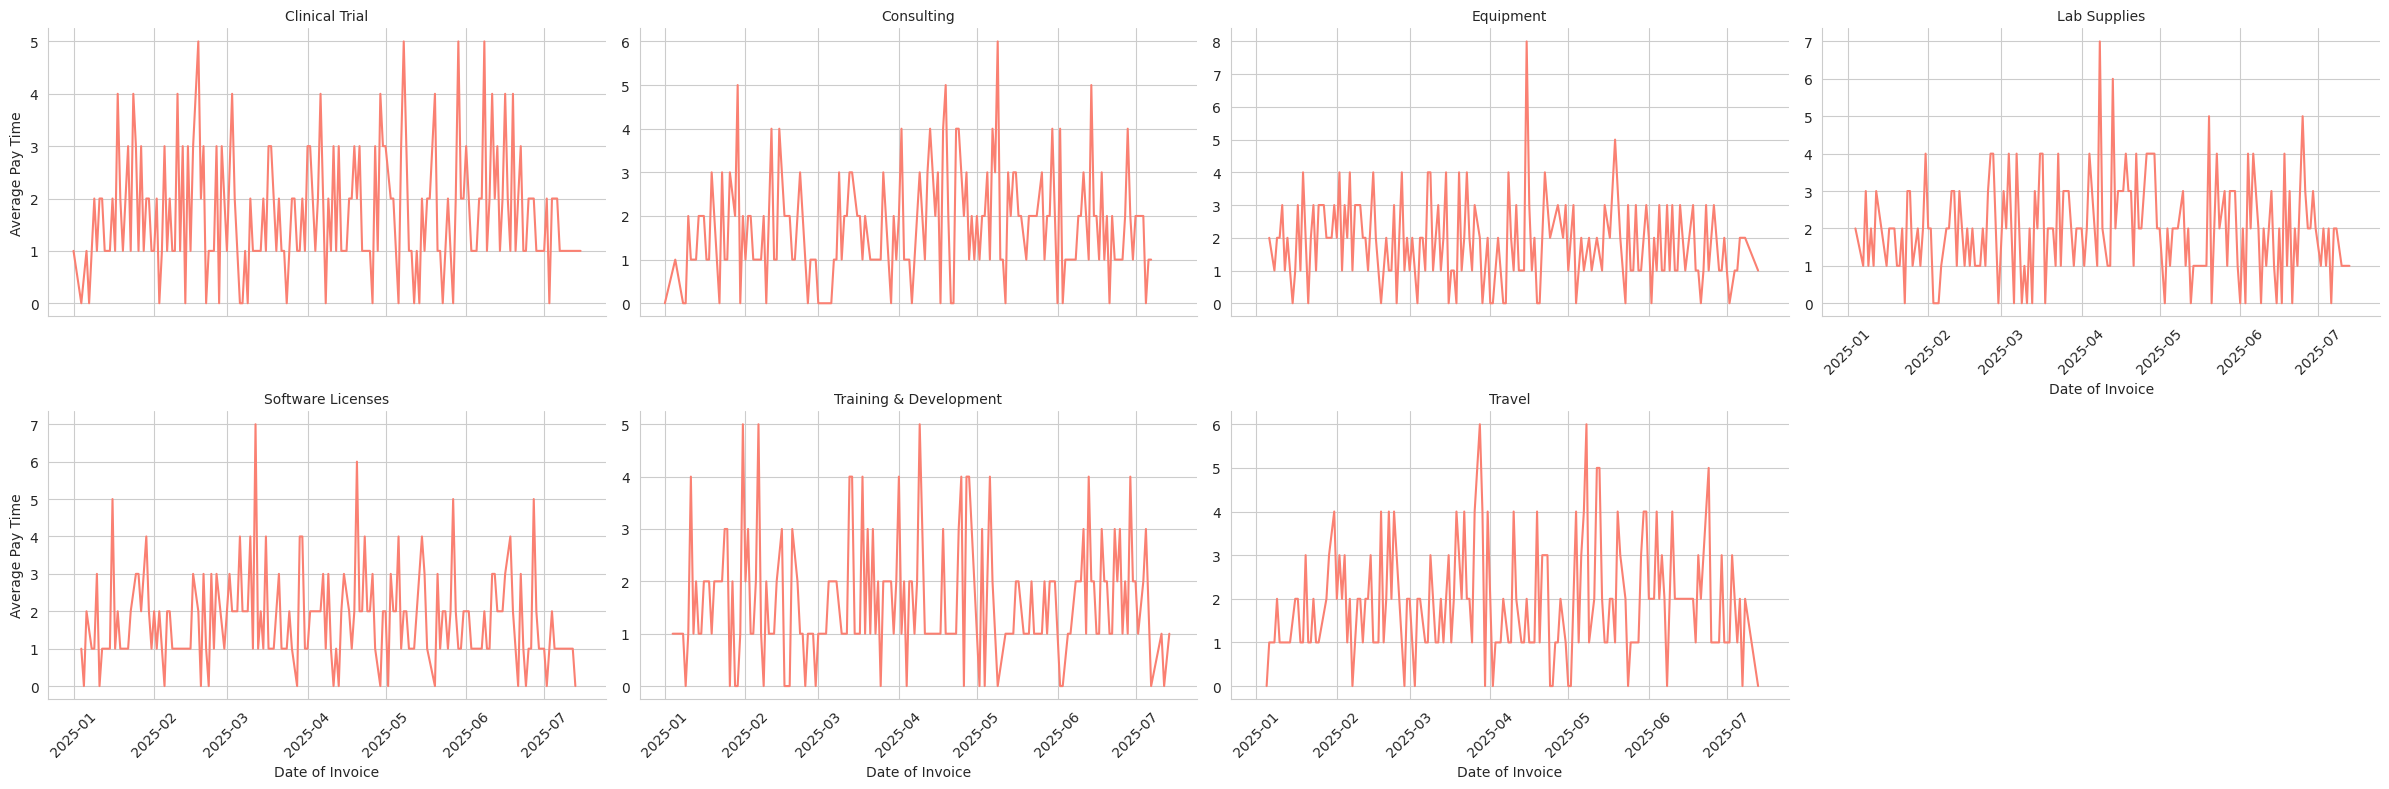

In [8]:
# Grouping by Category and Date to aggregate invoice values
plot_data = payment_merge.groupby(['Type of expense', 'Date of invoice'])['avg_pay_time'].count().reset_index()

# Plotting
sns.set_style("whitegrid")
g = sns.FacetGrid(plot_data, col="Type of expense", col_wrap=4, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "Date of invoice", "avg_pay_time",color="salmon")

# Formatting
g.set_titles("{col_name}")
g.set_axis_labels("Date of Invoice", "Average Pay Time")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

#Average payment time by expense type, value and location;

#Comparing each team spend against their budget.

In [9]:
payment_merge.groupby('Type of expense')['avg_pay_time'].mean()

,avg_pay_time
Type of expense,
Clinical Trial,18.69
Consulting,18.19
Equipment,19.10
Lab Supplies,18.40
Software Licenses,18.38
Training & Development,18.52
Travel,18.30


In [10]:
# Binning Invoice Value for categorical analysis
bins = [0, 4000, 8000, 12000, 16000, 20000]
labels = ['very low (<4k)','Low (<4k-8k)', 'Medium (8k-12k)', 'High (12k-16k)', 'Very High (>16k)']
payment_merge['Value Bin'] = pd.cut(payment_merge['Invoice value'], bins=bins, labels=labels)

# Average Payment Times
avg_pay_expense = payment_merge.groupby('Type of expense')['avg_pay_time'].mean()
avg_pay_location = payment_merge.groupby('Location')['avg_pay_time'].mean().sort_values()
avg_pay_value = payment_merge.groupby('Value Bin')['avg_pay_time'].mean()

/tmp/ipykernel_60357/1180094946.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pay_value = payment_merge.groupby('Value Bin')['avg_pay_time'].mean()


In [11]:
avg_pay_value

,avg_pay_time
Value Bin,
very low (<4k),18.31
Low (<4k-8k),18.53
Medium (8k-12k),18.29
High (12k-16k),18.95
Very High (>16k),18.37


#3. Outliers:

In [12]:
team_results = []
for team in payment_merge['Research team'].unique():
    team_subset = payment_merge[payment_merge['Research team'] == team].copy()

    # Z-score for Invoice value within the team
    iv_mean, iv_std = team_subset['Invoice value'].mean(), team_subset['Invoice value'].std()
    team_subset['zscore invoice'] = (team_subset['Invoice value'] - iv_mean) / iv_std

    # Z-score for avg_pay_time within the team
    pt_mean, pt_std = team_subset['avg_pay_time'].mean(), team_subset['avg_pay_time'].std()
    team_subset['zscore paytime'] = (team_subset['avg_pay_time'] - pt_mean) / pt_std

    team_results.append(team_subset)

df_team_z = pd.concat(team_results)

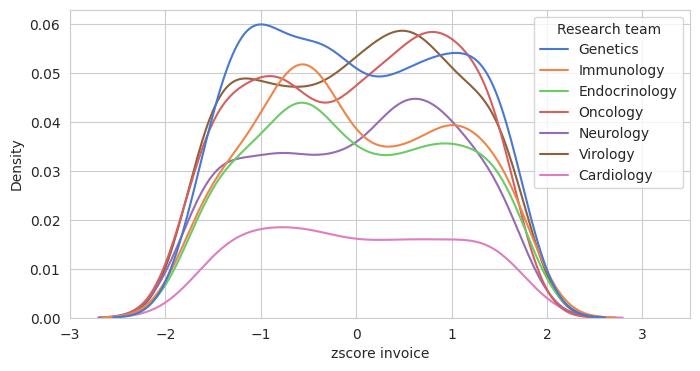

In [13]:
plt.figure(figsize=(8, 4))
ax= sns.kdeplot(data=df_team_z, x="zscore invoice", hue="Research team",palette="muted")
ax.set_xlim(-3, 3.5)
sns.move_legend(ax, loc="upper right")

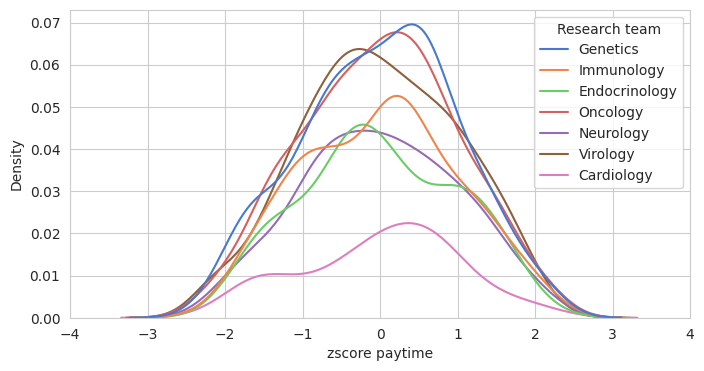

In [14]:
plt.figure(figsize=(8, 4))
ax= sns.kdeplot(data=df_team_z, x="zscore paytime", hue="Research team",palette="muted")
ax.set_xlim(-4, 4)
sns.move_legend(ax, loc="upper right")

#2. What impacts the time taken to pay the invoice/ request:

Feature Creation:


---


1.   days_to_receive: wait time between invoice creation and receipt
2.   Payment authoriser role/designation

In [15]:
# The 'Date received' and 'Date of invoice' columns are already datetime objects from previous processing.
payment_merge['days_to_receive'] = (payment_merge['Date received'] - payment_merge['Date of invoice']).dt.days

In [16]:
# get location of payment
payment_merge=payment_merge.merge(members[members['Team']=='Payments'][['Name','Role']].drop_duplicates(), how='left', left_on='Payment authoriser', right_on='Name', suffixes=("","_authorizer")).drop(columns=['Name'])
payment_merge['Role_authorizer']=payment_merge['Role_authorizer'].fillna("Director")
payment_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2978 entries, 0 to 2977
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date received          2978 non-null   datetime64[ns]
 1   Research team          2978 non-null   object        
 2   Submitted by           2978 non-null   object        
 3   Date of invoice        2978 non-null   datetime64[ns]
 4   Invoice number         2978 non-null   object        
 5   Description of spend   2978 non-null   object        
 6   Invoice value          2978 non-null   float64       
 7   Date of authorisation  2978 non-null   datetime64[ns]
 8   Authorised by          2978 non-null   object        
 9   Payment due date       2978 non-null   datetime64[ns]
 10  Date of payment        2111 non-null   datetime64[ns]
 11  Payment amount         2111 non-null   float64       
 12  Payment authoriser     2978 non-null   object        
 13  Pay

In [17]:
for i in ['Type of expense', 'Location', 'Role',"Role_authorizer"]:
  payment_merge[i+"_encoded"] = payment_merge[i].map(payment_merge.groupby(i)['avg_pay_time'].median().to_dict())

In [18]:
# Select predictors
features = ['Invoice value', 'days_to_receive', 'Annual budget',
       'Type of expense_encoded', 'Location_encoded', 'Role_encoded',
       'Role_authorizer_encoded']
X = payment_merge[features].fillna(0)
X.columns=['Invoice value', 'days_to_receive', 'Annual budget',
       'Type of expense', 'Location', 'Role','Role_authorizer']
y = payment_merge['avg_pay_time'].fillna(0)

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2978 entries, 0 to 2977
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Invoice value    2978 non-null   float64
 1   days_to_receive  2978 non-null   int64  
 2   Annual budget    2978 non-null   float64
 3   Type of expense  2978 non-null   float64
 4   Location         2978 non-null   float64
 5   Role             2978 non-null   float64
 6   Role_authorizer  2978 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 163.0 KB


In [20]:
X_vif = sm.add_constant(X)
X_vif

,Invoice value,days_to_receive,Annual budget,Type of expense,Location,Role,Role_authorizer
0,13319.94,13,48398165.75,19.00,19.00,19.00,19.00
1,14696.98,5,80093835.11,19.00,18.00,19.00,19.00
2,10908.06,10,81254909.11,18.00,18.00,19.00,19.00
3,13541.31,14,89358802.58,18.00,18.00,19.00,19.00
4,524.33,7,80093835.11,18.00,19.00,19.00,19.00
...,...,...,...,...,...,...,...
2973,14219.56,12,81254909.11,19.00,18.00,19.00,19.00
2974,5972.82,14,48398165.75,18.00,19.00,19.00,19.00
2975,6208.99,3,66429524.51,19.00,19.00,19.00,19.00
2976,19555.53,5,89358802.58,19.00,19.00,19.00,19.00


R-squared: 0.001
Adj R-squared: -0.001


Text(0.5, 1.0, 'Residuals vs Predicted Values')

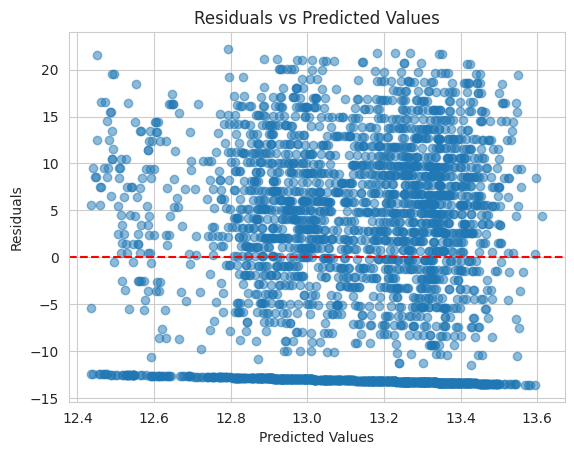

In [21]:
import matplotlib.pyplot as plt

model = sm.OLS(y, X_vif).fit()
print(f"R-squared: {model.rsquared:.3f}")
print(f"Adj R-squared: {model.rsquared_adj:.3f}")

# Residual Plot
y_pred = model.predict(X_vif)
residuals = y - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

In [22]:
beta_stats = pd.DataFrame({
    'Beta': model.params,
    'Std.Error': model.bse,
    't-stat': model.tvalues,
    'p-value': model.pvalues
})

# Concatenate confidence intervals (95% default)
beta_stats = pd.concat([beta_stats, model.conf_int()], axis=1)
beta_stats.rename(columns={0: 'Lower 95%', 1: 'Upper 95%'}, inplace=True)

# Filter for statistically significant variables (p < 0.05)
significant_vars = beta_stats[beta_stats['p-value'] < 0.05]

In [23]:
beta_stats[['Beta','p-value']].T

,Invoice value,days_to_receive,Annual budget,Type of expense,Location,Role,Role_authorizer
Beta,-0.00,0.01,0.00,0.08,0.36,-0.31,0.56
p-value,0.73,0.82,0.79,0.83,0.41,0.71,0.37


# Additional Section: A fraud detection approach
1. Reference: the Fraud Cases Master dataset
2. An explanation of features, modelling logic, and how outputs would be used by Internal Audit.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
pd.options.display.float_format = '{:.3f}'.format
pd.options.display.max_columns=100

One hot encoding

In [25]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
fraud_enco = encoder.fit_transform(payment_merge[['Type of expense','Location','Research team','Value Bin']])
payment_merge[encoder.get_feature_names_out(['Type of expense','Location','Research team','Value Bin'])]=fraud_enco
payment_merge.columns

Index(['Date received', 'Research team', 'Submitted by', 'Date of invoice',
       'Invoice number', 'Description of spend', 'Invoice value',
       'Date of authorisation', 'Authorised by', 'Payment due date',
       'Date of payment', 'Payment amount', 'Payment authoriser',
       'Payment Status', 'Type of expense', 'Company', 'data', 'Fraud flag',
       'Location', 'Role', 'avg_pay_time', 'Annual budget', 'Value Bin',
       'days_to_receive', 'Role_authorizer', 'Type of expense_encoded',
       'Location_encoded', 'Role_encoded', 'Role_authorizer_encoded',
       'Type of expense_Clinical Trial', 'Type of expense_Consulting',
       'Type of expense_Equipment', 'Type of expense_Lab Supplies',
       'Type of expense_Software Licenses',
       'Type of expense_Training & Development', 'Type of expense_Travel',
       'Location_Boston', 'Location_London', 'Location_Munich',
       'Location_Singapore', 'Location_Zurich', 'Research team_Cardiology',
       'Research team_Endocrinolo

In [26]:
fraud=payment_merge[payment_merge['data']=='fraud'][['Date received', 'Research team', 'Submitted by', 'Date of invoice',
       'Invoice number', 'Invoice value', 'Authorised by', 'Payment amount', 'Payment authoriser', 'Type of expense', 'Company', 'Fraud flag',
       'Location', 'Role', 'avg_pay_time', 'Annual budget','days_to_receive', 'Role_authorizer','Type of expense_Clinical Trial', 'Type of expense_Consulting',
       'Type of expense_Equipment', 'Type of expense_Lab Supplies',
       'Type of expense_Software Licenses',
       'Type of expense_Training & Development', 'Type of expense_Travel',
       'Location_Boston', 'Location_London', 'Location_Munich',
       'Location_Singapore', 'Location_Zurich','Research team_Virology',
       'Research team_Endocrinology', 'Research team_Immunology', 'Research team_Neurology','Research team_Oncology']]

print("Raw Fraud dataset shape: ", fraud.shape)
fraud=fraud.dropna(subset=['Fraud flag'])
print("Dropped rows where Fraud tag is not available: ", fraud.shape)

Raw Fraud dataset shape:  (1000, 35)
Dropped rows where Fraud tag is not available:  (1000, 35)


In [27]:
for i in ['Location','Research team','Payment authoriser','Type of expense','Role']:
  display(fraud.groupby(i).agg({'Invoice value': 'sum','Invoice number':'count','Fraud flag': 'mean'}))

,Invoice value,Invoice number,Fraud flag
Location,,,
Boston,2423984.630,229,0.039
London,1076423.270,106,0.000
Munich,2644060.470,253,0.075
Singapore,2089424.510,210,0.057
Zurich,2152078.900,202,0.050


,Invoice value,Invoice number,Fraud flag
Research team,,,
Cardiology,422714.690,44,0.000
Endocrinology,1485696.270,141,0.071
Genetics,1856241.940,189,0.063
Immunology,1418843.530,149,0.067
Neurology,1326184.670,121,0.074
Oncology,1957924.360,176,0.000
Virology,1918366.320,180,0.050


,Invoice value,Invoice number,Fraud flag
Payment authoriser,,,
Antonio Wilson,9758076.840,776,0.059
Christian Walsh,3099.770,4,0.000
James Smith,610853.900,203,0.020
Kim Johnson,7023.060,9,0.000
Robert Day,6918.210,8,0.000


,Invoice value,Invoice number,Fraud flag
Type of expense,,,
Clinical Trial,1626214.310,159,0.019
Consulting,1312797.670,133,0.045
Equipment,1468729.860,147,0.061
Lab Supplies,1434733.020,134,0.052
Software Licenses,1471953.440,140,0.071
Training & Development,1392234.710,131,0.069
Travel,1679308.770,156,0.038


,Invoice value,Invoice number,Fraud flag
Role,,,
Analyst,8155159.580,787,0.048
Manager,2230812.200,213,0.056


Distribution of predicted fraud probability: 


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
pred_fraud_prob,700.000,0.262,0.339,0.000,0.000,0.000,0.000,0.508,0.776,0.855,0.902


Distribution of predicted fraud probability: 


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
pred_fraud_prob,700.000,0.262,0.339,0.000,0.000,0.000,0.000,0.508,0.776,0.855,0.902


Model Performance: Train 
[[492 174]
 [  3  31]]
              precision    recall  f1-score   support

         0.0       0.99      0.74      0.85       666
         1.0       0.15      0.91      0.26        34

    accuracy                           0.75       700
   macro avg       0.57      0.83      0.55       700
weighted avg       0.95      0.75      0.82       700

Model Performance: Train 
[[210  74]
 [  2  14]]
              precision    recall  f1-score   support

         0.0       0.99      0.74      0.85       284
         1.0       0.16      0.88      0.27        16

    accuracy                           0.75       300
   macro avg       0.57      0.81      0.56       300
weighted avg       0.95      0.75      0.82       300



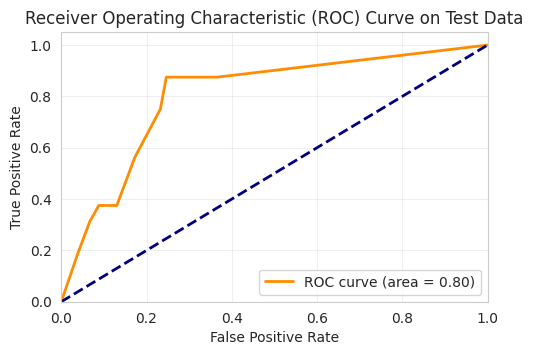

In [87]:
# Stratified sampling (70:30)
fraud_train,fraud_test = train_test_split(fraud, test_size=0.3, random_state=7, stratify=fraud[['Fraud flag','Location','Research team']])
#X_Var= ['Invoice value','Annual budget','Type of expense_encoded','Location_encoded','Company_encoded','Role_encoded']
X_Var=['Invoice value','Type of expense_Clinical Trial',
       'Type of expense_Software Licenses',
       'Type of expense_Training & Development', 'Type of expense_Travel',
       'Location_Boston', 'Location_London', 'Location_Munich',
       'Location_Singapore','Research team_Virology',
       'Research team_Endocrinology', 'Research team_Immunology', 'Research team_Neurology','Research team_Oncology']
# Decision Tree with class weight to tackle imbalanced class
model = DecisionTreeClassifier(criterion='gini', max_depth=10,min_samples_leaf=20, min_samples_split=30,min_impurity_decrease=.001,
    class_weight='balanced' ,min_weight_fraction_leaf=0.0, random_state=42)

model.fit(fraud_train[X_Var], fraud_train['Fraud flag'])

fraud_train['pred_fraud_prob'] = model.predict_proba(fraud_train[X_Var])[:, 1]
fraud_train['pred_fraud'] = np.where(fraud_train['pred_fraud_prob']>=.5,1,0)
print("Distribution of predicted fraud probability: ")
display(fraud_train['pred_fraud_prob'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,.95]).to_frame().T)
fraud_test['pred_fraud_prob'] = model.predict_proba(fraud_test[X_Var])[:, 1]
fraud_test['pred_fraud'] = np.where(fraud_test['pred_fraud_prob']>=.5,1,0)
print("Distribution of predicted fraud probability: ")
display(fraud_train['pred_fraud_prob'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,.95]).to_frame().T)

print("Model Performance: Train ")
print(confusion_matrix(fraud_train['Fraud flag'], fraud_train['pred_fraud']))
print(classification_report(fraud_train['Fraud flag'], fraud_train['pred_fraud']))

print("Model Performance: Train ")
print(confusion_matrix(fraud_test['Fraud flag'], fraud_test['pred_fraud']))
print(classification_report(fraud_test['Fraud flag'], fraud_test['pred_fraud']))

# AUC ROC
fpr, tpr, thresholds = roc_curve(fraud_test['Fraud flag'], fraud_test['pred_fraud_prob'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5.5, 3.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Data')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

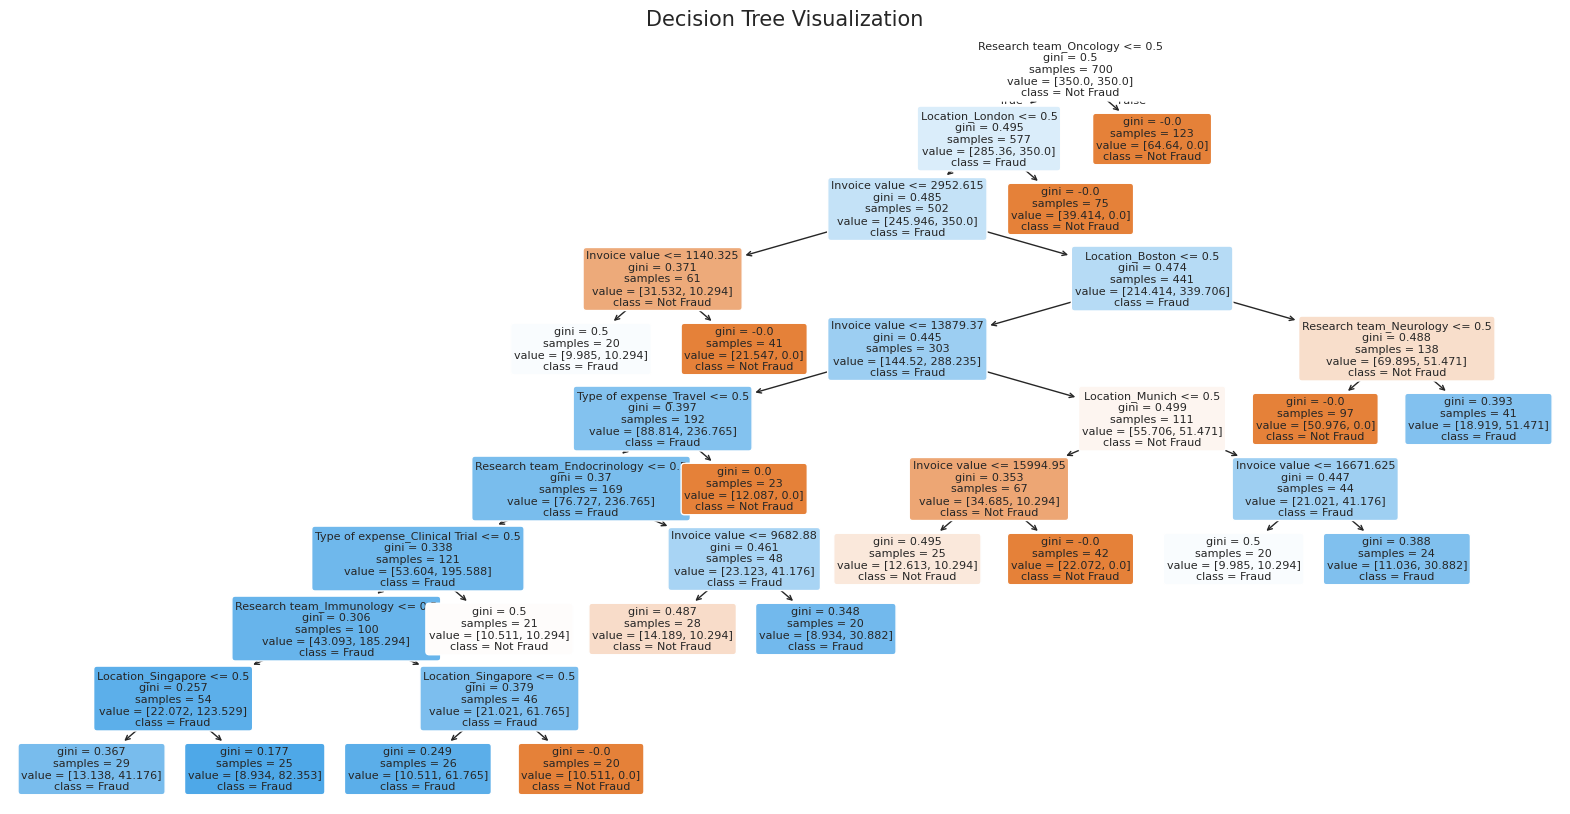

In [88]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=X_Var,
          class_names=['Not Fraud', 'Fraud'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Visualization', fontsize=15)
plt.show()

In [89]:
#from sklearn.tree import export_text

#tree_rules = export_text(model, feature_names=list(X_Var))
#print(tree_rules)

In [147]:
import shap
explainer = shap.TreeExplainer(model, fraud_train[fraud_train['pred_fraud_prob'].between(.4,.55)][X_Var].head(1))
shap_values = explainer.shap_values(fraud_test[X_Var])
fraud_test[[i + "_shap" for i in X_Var]]=shap_values[:, :, 1]
fraud_test.head()

,Date received,Research team,Submitted by,Date of invoice,Invoice number,Invoice value,Authorised by,Payment amount,Payment authoriser,Type of expense,Company,Fraud flag,Location,Role,avg_pay_time,Annual budget,days_to_receive,Role_authorizer,Type of expense_Clinical Trial,Type of expense_Consulting,Type of expense_Equipment,Type of expense_Lab Supplies,Type of expense_Software Licenses,Type of expense_Training & Development,Type of expense_Travel,Location_Boston,Location_London,Location_Munich,Location_Singapore,Location_Zurich,Research team_Virology,Research team_Endocrinology,Research team_Immunology,Research team_Neurology,Research team_Oncology,pred_fraud_prob,pred_fraud,Invoice value_shap,Type of expense_Clinical Trial_shap,Type of expense_Software Licenses_shap,Type of expense_Training & Development_shap,Type of expense_Travel_shap,Location_Boston_shap,Location_London_shap,Location_Munich_shap,Location_Singapore_shap,Research team_Virology_shap,Research team_Endocrinology_shap,Research team_Immunology_shap,Research team_Neurology_shap,Research team_Oncology_shap
2088,2025-02-11,Oncology,Erica Smith,2025-01-31,INV-60031,5889.360,Belinda Holmes,5889.360,Antonio Wilson,Travel,IG Group Holdings,0.000,Singapore,Analyst,9.000,89358802.580,11,Director,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0,-0.071,-0.011,0.000,0.000,-0.086,0.000,0.000,0.000,0.000,0.000,0.000,0.030,0.000,-0.311
2251,2025-03-10,Neurology,Gregory Reed,2025-03-03,INV-25811,15693.540,Adam Simmons,15693.540,Antonio Wilson,Training & Development,Renishaw,0.000,London,Analyst,8.000,91981613.230,7,Director,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,0.000,-0.449,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2455,2025-03-20,Immunology,Robert Whitney,2025-03-08,INV-94686,2099.720,James Joseph,2099.720,James Smith,Training & Development,IG Group Holdings,0.000,Singapore,Analyst,16.000,80093835.110,12,Manager,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0,-0.449,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2630,2025-01-27,Endocrinology,Brandy Fisher,2025-01-20,INV-69525,16265.120,Michael Reyes,16265.120,Antonio Wilson,Clinical Trial,Guinness Peat Group,0.000,Zurich,Analyst,15.000,81254909.110,7,Director,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0,-0.449,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2744,2025-06-04,Genetics,Isaac Gonzalez,2025-05-24,INV-73882,3433.000,Kathryn Campbell,NaN,James Smith,Travel,Auction Technology Group,0.000,Singapore,Analyst,NaN,48398165.750,11,Manager,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,-0.209,-0.007,0.000,0.000,-0.308,0.000,0.000,0.000,0.000,0.000,0.000,0.075,0.000,0.000


to check fraud cases on payments data

In [148]:
payments=payment_merge[payment_merge['data']=='payments'][['Date received', 'Research team', 'Submitted by', 'Date of invoice',
       'Invoice number', 'Invoice value', 'Authorised by', 'Payment amount', 'Payment authoriser', 'Type of expense', 'Company', 'Fraud flag',
       'Location', 'Role', 'avg_pay_time', 'Annual budget','days_to_receive', 'Role_authorizer','Type of expense_Clinical Trial', 'Type of expense_Consulting',
       'Type of expense_Equipment', 'Type of expense_Lab Supplies',
       'Type of expense_Software Licenses',
       'Type of expense_Training & Development', 'Type of expense_Travel',
       'Location_Boston', 'Location_London', 'Location_Munich',
       'Location_Singapore', 'Location_Zurich','Research team_Virology',
       'Research team_Endocrinology', 'Research team_Immunology', 'Research team_Neurology','Research team_Oncology','Value Bin_High (12k-16k)', 'Value Bin_Low (<4k-8k)',
       'Value Bin_Medium (8k-12k)', 'Value Bin_Very High (>16k)']]
for i in ['Company','Role']:
  payments[i+"_encoded"] = payments[i].map(fraud_train.groupby(i)['Fraud flag'].count().to_dict())

payments['pred_fraud_prob'] = model.predict_proba(payments[X_Var])[:, 1]
payments['pred_fraud'] = model.predict(payments[X_Var])
print("Distribution of predicted fraud probability: ")
display(payments['pred_fraud_prob'].describe(percentiles=[0.1,0.25,0.5,.70,0.75,.95,.99]).to_frame().T)

Distribution of predicted fraud probability: 


,count,mean,std,min,10%,25%,50%,70%,75%,95%,99%,max
pred_fraud_prob,1978.000,0.244,0.330,0.000,0.000,0.000,0.000,0.449,0.508,0.855,0.902,0.902


In [149]:
# SHAP Explainibility

In [154]:
payments[[i + "_shap" for i in X_Var]]=explainer.shap_values(payments[X_Var])[:, :, 1]
payments[payments["pred_fraud_prob"]>=.901].shape

(54, 57)

Displaying Force Plot for Invoice Number: INV-73458 (Predicted Fraud Probability: 0.902)


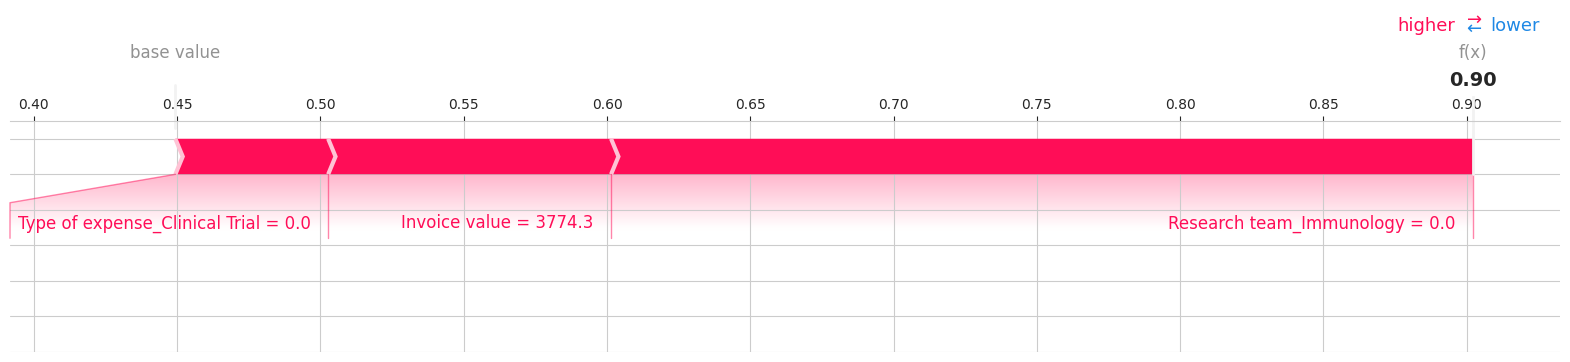

In [151]:
highest_prob_case = payments.sort_values(by='pred_fraud_prob', ascending=False).head(1)

shap_values = highest_prob_case.filter(like='_shap').values
feature_values_single_case = highest_prob_case[X_Var].values
base_value = explainer.expected_value[1]

print(f"Displaying Force Plot for Invoice Number: {highest_prob_case['Invoice number'].iloc[0]} (Predicted Fraud Probability: {highest_prob_case['pred_fraud_prob'].iloc[0]:.3f})")

shap.initjs()
shap.plots.force(base_value,shap_values,
    features=feature_values_single_case,
    feature_names=X_Var,
    matplotlib=True)

In [152]:
df=(payments[[i + "_shap" for i in X_Var]].mean()*100).sort_values(ascending=False)

/tmp/ipykernel_60357/1221799565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_filtered.values, y=df_filtered.index, palette='crest')


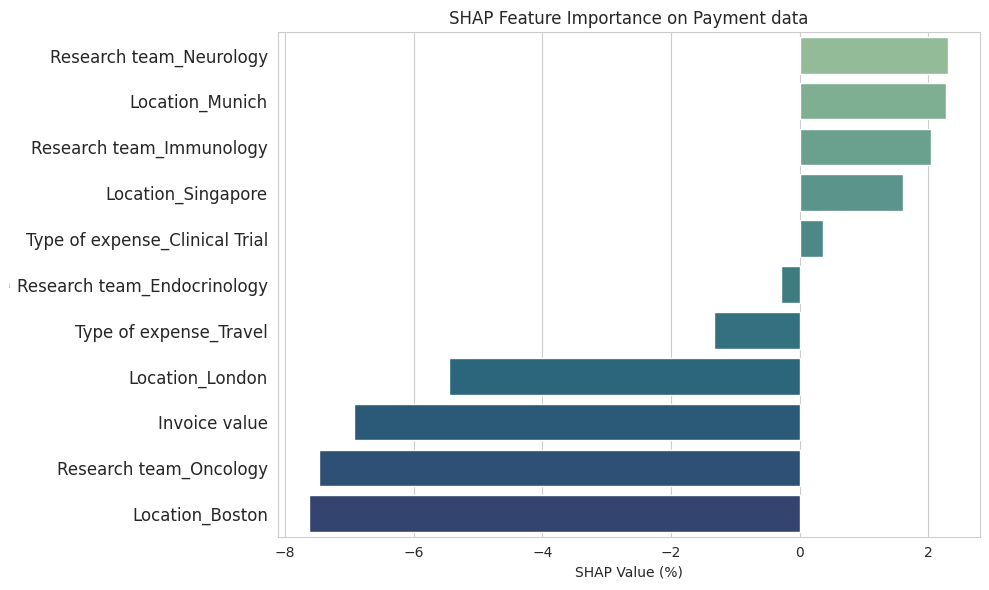

In [153]:
df_filtered = df[df != 0]
df_filtered.index = df_filtered.index.str.split("_shap").str[0]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=df_filtered.values, y=df_filtered.index, palette='crest')
plt.title('SHAP Feature Importance on Payment data')
plt.xlabel('SHAP Value (%)')
plt.ylabel('Feature',fontsize=0)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

# To check if Logistic Regression can perform better.

         Current function value: 0.164395
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:             Fraud flag   No. Observations:                  700
Model:                          Logit   Df Residuals:                      685
Method:                           MLE   Df Model:                           14
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1539
Time:                        17:39:27   Log-Likelihood:                -115.08
converged:                      False   LL-Null:                       -136.00
Covariance Type:            nonrobust   LLR p-value:                 0.0001306
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Invoice value                          -2.616e-05   3.04e-05     -0.860      0.390   -8.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
pred_fraud_prob,700.000,0.054,0.067,0.000,0.000,0.000,0.024,0.116,0.159,0.176,0.247


Model Performance: Train 
[[513 153]
 [ 13  21]]
              precision    recall  f1-score   support

         0.0       0.98      0.77      0.86       666
         1.0       0.12      0.62      0.20        34

    accuracy                           0.76       700
   macro avg       0.55      0.69      0.53       700
weighted avg       0.93      0.76      0.83       700

Model Performance: Train 
[[224  60]
 [  8   8]]
              precision    recall  f1-score   support

         0.0       0.97      0.79      0.87       284
         1.0       0.12      0.50      0.19        16

    accuracy                           0.77       300
   macro avg       0.54      0.64      0.53       300
weighted avg       0.92      0.77      0.83       300



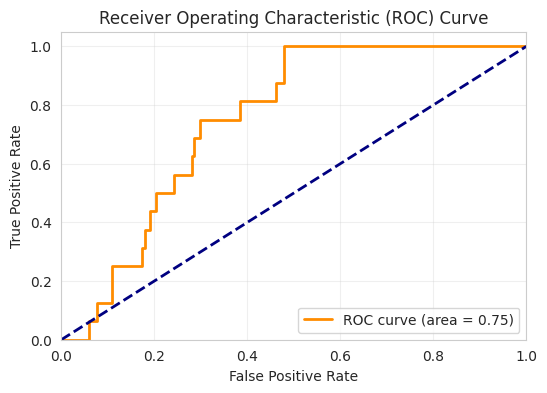

In [630]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(fraud_train[X_Var])
X_test_sm = sm.add_constant(fraud_test[X_Var])

model_sm = sm.Logit(fraud_train['Fraud flag'], fraud_train[X_Var]).fit()
print(model_sm.summary())

# Predict probabilities
fraud_train['pred_fraud_prob'] = model_sm.predict(fraud_train[X_Var])
fraud_test['pred_fraud_prob'] = model_sm.predict(fraud_test[X_Var])

print("Distribution of predicted fraud probability: ")
display(fraud_train['pred_fraud_prob'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,.95]).to_frame().T)

fraud_train['pred_fraud'] = (fraud_train['pred_fraud_prob'] > 0.116).astype(int)
fraud_test['pred_fraud'] = (fraud_test['pred_fraud_prob'] > 0.116).astype(int)

print("Model Performance: Train ")
print(confusion_matrix(fraud_train['Fraud flag'], fraud_train['pred_fraud']))
print(classification_report(fraud_train['Fraud flag'], fraud_train['pred_fraud']))

print("Model Performance: Train ")
print(confusion_matrix(fraud_test['Fraud flag'], fraud_test['pred_fraud']))
print(classification_report(fraud_test['Fraud flag'], fraud_test['pred_fraud']))

# AUC ROC
fpr, tpr, thresholds = roc_curve(fraud_test['Fraud flag'], fraud_test['pred_fraud_prob'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#SECTION 2: NLP

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

descriptions = payment_merge['Description of spend'].tolist()

# Load DistilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

def get_embed(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

# Generate vectors for all descriptions
X = [get_embed(doc) for doc in descriptions]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


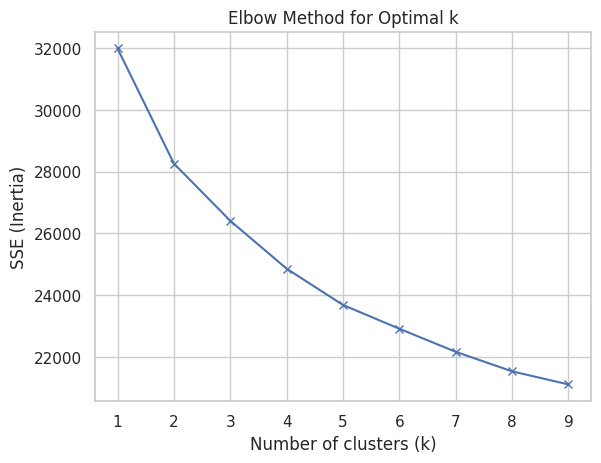

In [ ]:
sse = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Plot Elbow
plt.plot(K, sse, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

# Apply final clustering (k=4 based on the elbow)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
payment_merge['Cluster_Label'] = kmeans.fit_predict(X)

In [ ]:
payment_merge[['Cluster_Label','Invoice value']].groupby('Cluster_Label').sum()

,Invoice value
Cluster_Label,
0,7141953.71
1,5504764.12
2,5637736.12
3,12211156.96


In [ ]:
for i in range(4):
    print(f"--- Cluster {i} ---")

    cluster_text = payment_merge[payment_merge['Cluster_Label'] == i]['Description of spend'].str.lower()

    vec_bi = CountVectorizer(stop_words=custom_stopwords, ngram_range=(2,2), max_features=3)
    bow_bi = vec_bi.fit_transform(cluster_text)
    sum_words_bi = bow_bi.sum(axis=0)
    words_freq_bi = [(word, sum_words_bi[0, idx]) for word, idx in vec_bi.vocabulary_.items()]
    words_freq_bi = pd.DataFrame(sorted(words_freq_bi, key = lambda x: x[1], reverse=True),columns=['Words', 'Frequency'])
    display(list(words_freq_bi['Words']))

--- Cluster 0 ---


['elisa kits', 'quantify cytokine', 'cancer immunotherapy']

--- Cluster 1 ---


['personal protective', 'protective equipment', 'equipment ppe']

--- Cluster 2 ---


['software licenses', 'databases literature', 'variant interpretation']

--- Cluster 3 ---


['immune cell', 'extraction kits', 'gene expression']

In [ ]:
feedback=pd.read_csv('https://raw.githubusercontent.com/shin-jini/BUPA_Case_Study/main/Payement_Information/Customer_Feedback_Master.csv')

#Rating Analysis
print(feedback['Rating'].value_counts(normalize=True))

# Monthly Trend Analysis for negative ratings
feedback['Date'] = pd.to_datetime(feedback['Date'], format='%d/%m/%Y')
feedback['month_year'] = feedback['Date'].dt.to_period('M')
feedback["rating_negative"]=np.where(feedback['Rating']<=2,1,0)
trend = feedback[['rating_negative','month_year']].groupby('month_year').mean()

Rating
5   0.62
1   0.18
4   0.08
2   0.07
3   0.05
Name: proportion, dtype: float64


/tmp/ipykernel_23580/2718056061.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')


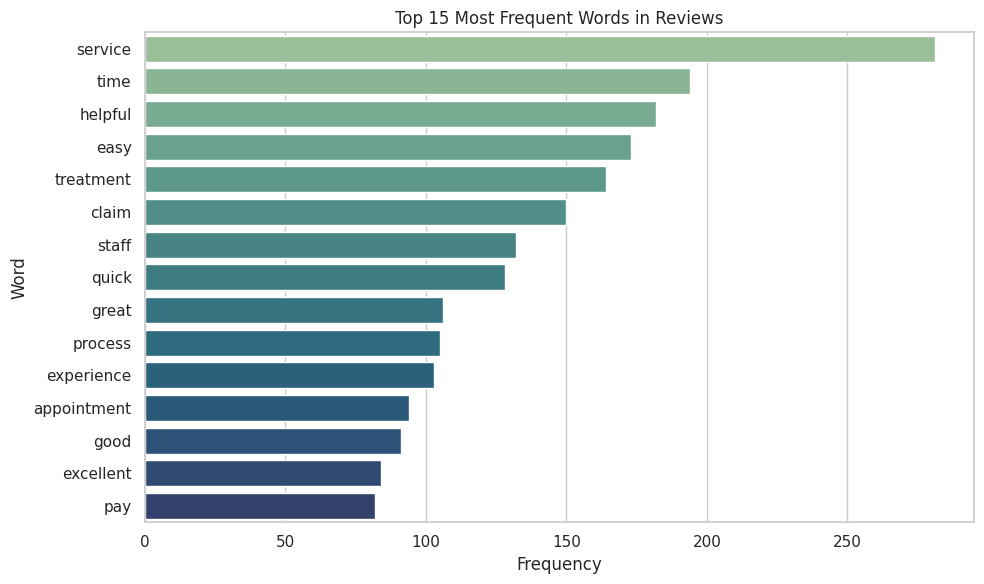

In [ ]:
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Drop missing reviews
feedback = feedback.dropna(subset=['Review'])

# Text Cleaning
stop_words = set(stopwords.words('english'))
# useless words in this context
custom_stopwords = list(stop_words) + ['abc', 'healthcare','get','phone','call','would','customer','years','really']

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

feedback['Clean_Review'] = feedback['Review'].apply(clean_text)

# Top Words
vec = CountVectorizer(stop_words=custom_stopwords, max_features=20)
bow = vec.fit_transform(feedback['Clean_Review'])
sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

words_df = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])

# Plot Top Words
plt.figure(figsize=(10, 6))
sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')
plt.title('Top 15 Most Frequent Words in Reviews')
plt.tight_layout()

/tmp/ipykernel_23580/3551243408.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')


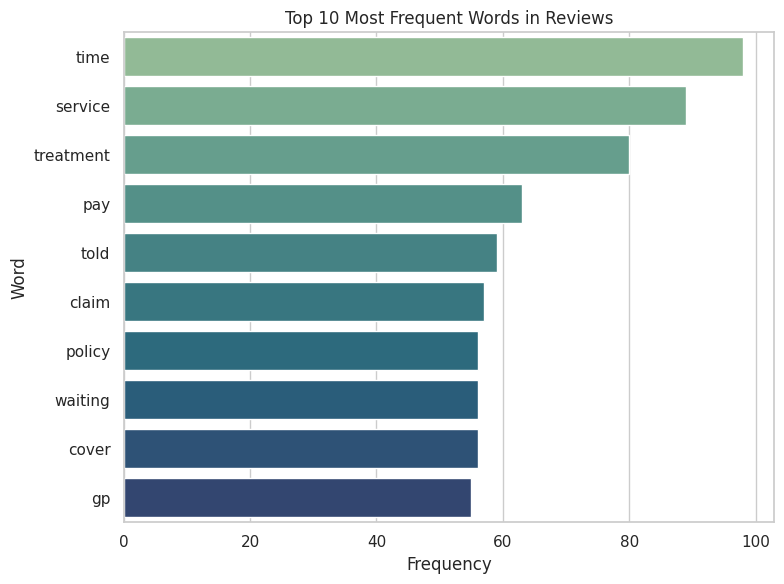

In [ ]:
# Top Words
vec = CountVectorizer(stop_words=custom_stopwords, max_features=10)
bow = vec.fit_transform(feedback[feedback['Rating']<=2]['Clean_Review'])
sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

words_df = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])

# Plot Top Words
plt.figure(figsize=(8, 6))
sns.barplot(data=words_df.head(15), x='Frequency', y='Word', palette='crest')
plt.title('Top 10 Most Frequent Words in Reviews')
plt.tight_layout()

/tmp/ipykernel_23580/1379976108.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_freq_bi.head(10), x='Frequency', y='Words', palette='crest')


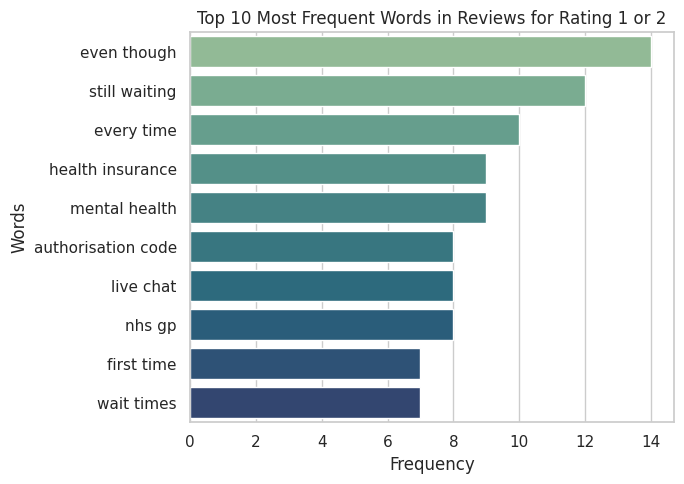

In [ ]:
vec_bi = CountVectorizer(stop_words=custom_stopwords, ngram_range=(2,2), max_features=10)
bow_bi = vec_bi.fit_transform(feedback[feedback['Rating']<=2]['Clean_Review'])
sum_words_bi = bow_bi.sum(axis=0)
words_freq_bi = [(word, sum_words_bi[0, idx]) for word, idx in vec_bi.vocabulary_.items()]
words_freq_bi = pd.DataFrame(sorted(words_freq_bi, key = lambda x: x[1], reverse=True),columns=['Words', 'Frequency'])

# Plot Top Words
plt.figure(figsize=(7, 5))
sns.barplot(data=words_freq_bi.head(10), x='Frequency', y='Words', palette='crest')
plt.title('Top 10 Most Frequent Words in Reviews for Rating 1 or 2')
plt.tight_layout()

In [ ]:
df=pd.DataFrame(feedback['Review'].str.len())
df[df['Review']>512]

,Review
0,674
1,1295
11,786
13,532
18,963
...,...
921,1365
923,597
925,674
928,600


In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

results = classifier(feedback['Review'].tolist(), truncation=True, batch_size=32)

feedback['Sentiment'] = [res['label'] for res in results]
feedback['Confidence'] = [res['score'] for res in results]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
feedback['Sentiment'].value_counts(normalize=1)

,proportion
Sentiment,
POSITIVE,0.63
NEGATIVE,0.37
